<h1> Rice Leaf project</h1>


<h2>About Dataset</h2>
<ul type='circle'>
    <li><h4>Name: Rice leaf Dieseases</h4></li>
    <li><h4>Total number of photos: 120</h4></li>
    <li><h4>Leaf Smut photos: 40</h4></li>
    <li><h4>Brown Spot photos:40</h4></li>
    <li><h4>Bacterial Leaf Blight photos:40</h4></li>
    <li><h4>Target variable: Leaf Smut,Brown Spot,Bacterial Leaf Blight</h4></li>
</ul>
<hr>

<h3>Importing all necessary modules </h3>

In [30]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [31]:
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.metrics import confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import  image

<h3>Using Data augmentation since dataset is small</h3>

<h3>Code in below cell will apply following transformations on images:</h3>
<ol>
  <li><h3>Rescaling (Normalization): Pixel values are scaled from 0–255 to 0–1.</h3></li>

  <li><h3>Rotation: Images are randomly rotated up to ±40 degrees.</h3></li>

  <li><h3>Width Shift: Images are shifted horizontally up to 20% of the width.</h3></li>

  <li><h3>Height Shift: Images are shifted vertically up to 20% of the height.</h3></li>

  <li><h3>Shear Transformation: Images are slanted to create a shear effect.</h3></li>

  <li><h3>Zoom: Images are randomly zoomed in or out up to 20%.</h3></li>

  <li><h3>Horizontal Flip: Images are flipped left to right.</h3></li>

  <li><h3>Vertical Flip: Images are flipped upside down.</h3></li>

  <li><h3>Fill Mode: Empty pixels are filled using the nearest pixel values.</h3></li>

  <li><h3>Validation Split: 20% of the dataset is reserved for validation.</h3></li>
</ol>
<hr>

In [32]:
#setting up generator for Data augmentation pipeline
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% for validation
)

<h3>Using data augmentation is crucial for this project as there is limited number of images in each class</h3>
<h3> Data augmentation will apply various transformations on images so the model will not overfit and will be seeing same image in diferent form</h3>
<hr>

<h3>Importing the data </h3>

In [33]:
#uploading data from google drive
data_path="/content/drive/MyDrive/Dataset"
#Augmenting training data
train_datagen=datagen.flow_from_directory(
  data_path,
  target_size=(224, 224),
  batch_size=16,
  class_mode='categorical',
  subset='training'
)


val_generator = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


In [34]:
#printing total number of distinct classes
print(train_datagen.class_indices)

{'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


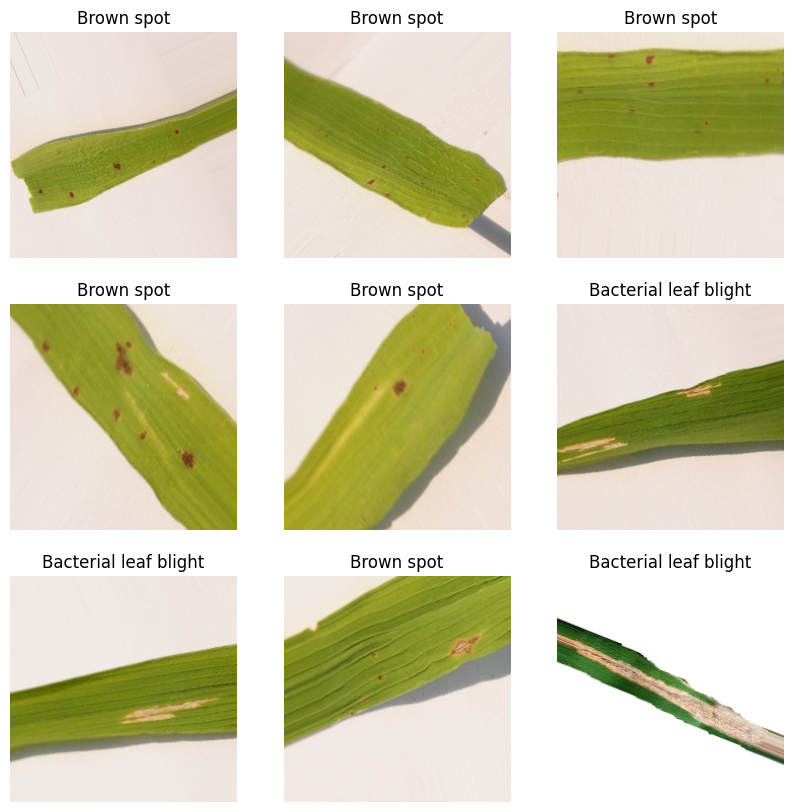

In [35]:
#viewing a few images
import matplotlib.pyplot as plt
images,labels = next(train_datagen)
class_names=list(train_datagen.class_indices.keys())

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.show()

<h3>Setting up the CNN model</h3>

In [36]:
#assigning necessary hyperparameters
base_model=tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    weights="imagenet",
    include_top=False
)
base_model.trainable=False
model=models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3,activation='softmax')
])

<h3>Setting up early stopping </h3>

In [37]:
#this will ensure the model stops training when there is no significant reduction in loss
#this also reduces chance of overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'riceLeaf.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)



<h3>Training the model on training data</h3>

In [38]:
epochs = 50

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_datagen,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.3646 - loss: 1.4578 - val_accuracy: 0.3478 - val_loss: 1.1780
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 726ms/step - accuracy: 0.3333 - loss: 1.4073 - val_accuracy: 0.4348 - val_loss: 1.0426
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.4062 - loss: 1.2858 - val_accuracy: 0.6957 - val_loss: 0.8597
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 724ms/step - accuracy: 0.5000 - loss: 1.0577 - val_accuracy: 0.7391 - val_loss: 0.7654
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 654ms/step - accuracy: 0.5521 - loss: 1.0571 - val_accuracy: 0.7391 - val_loss: 0.7625
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 941ms/step - accuracy: 0.5104 - loss: 1.0085 - val_accuracy: 0.7391 - val_loss: 0.6895
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - accuracy: 0.5417 - loss: 1.0429 - val_accuracy: 0.8261 - val_loss: 0.6290
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.6354 - loss: 0.8397 - val_accuracy: 0.8261 - val_loss: 0.57

<h3>Setting up data augmentator for validation data</h3>

In [39]:
val_generator = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 23 images belonging to 3 classes.


<h3>Predicting the model with validation data</h3>

In [40]:
y_pred=model.predict(val_generator)

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 5s/step


<h3>Converting probabilities into classes</h3>

In [41]:
#argmax will get the highest probabilities and map it to the respective class
y_pred_class=np.argmax(y_pred,axis=1)

In [42]:
true_classes=val_generator.classes
class_names = list(val_generator.class_indices.keys())

<h3>Model performance </h3>

In [43]:
print(classification_report(true_classes,y_pred_class,target_names=class_names))

                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.75      0.86         8
           Brown spot       0.88      0.88      0.88         8
            Leaf smut       0.78      1.00      0.88         7

             accuracy                           0.87        23
            macro avg       0.88      0.88      0.87        23
         weighted avg       0.89      0.87      0.87        23



<h3>Printing confusion matrix</h3>

In [44]:
conf_mat=confusion_matrix(true_classes,y_pred_class)

Text(95.7222222222222, 0.5, 'Actual values')

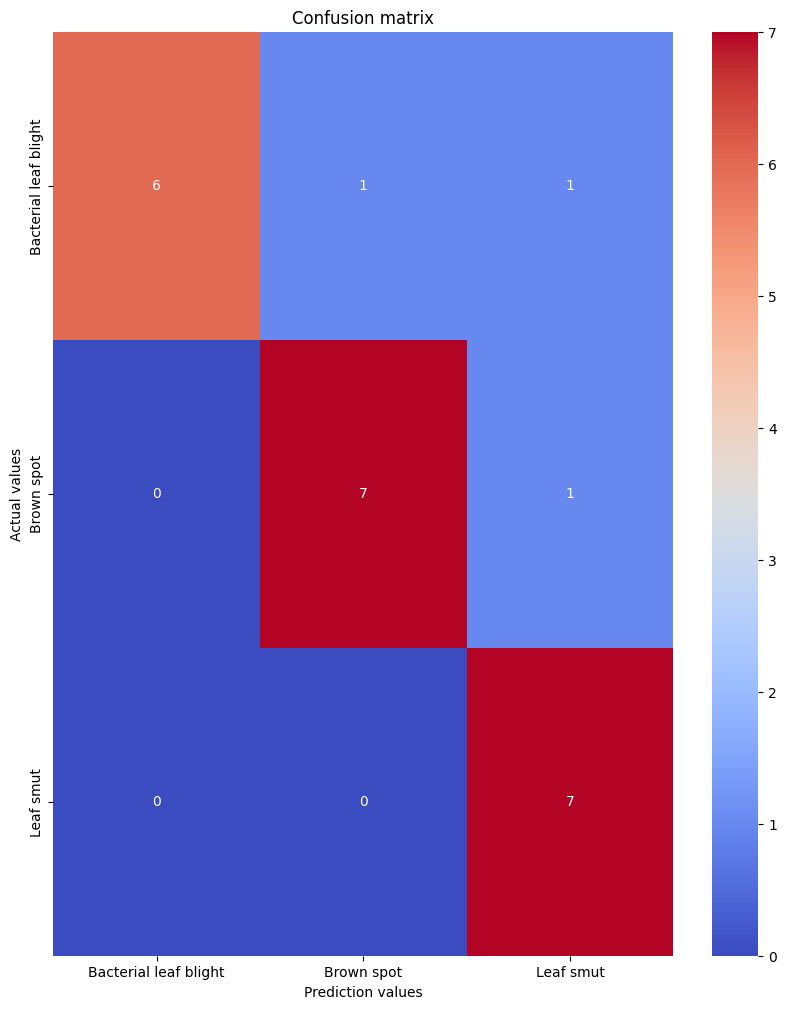

In [45]:
plt.figure(figsize=(10,12))
sns.heatmap(conf_mat,annot=True,cmap='coolwarm',xticklabels=class_names,yticklabels=class_names)
plt.title("Confusion matrix")
plt.xlabel("Prediction values")
plt.ylabel("Actual values")

<h3>Fine tuning the model </h3>

In [46]:
from tensorflow._api.v2.config import optimizer
base_model.trainable=True

#freezing first 100 layers of model
fine_tune_at=100
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable=False


model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_fine = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

fine_tune_checkpoint = ModelCheckpoint(
    'riceLeaf.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

epochs_fine = 20
history_fine = model.fit(
    train_datagen,
    validation_data=val_generator,
    epochs=epochs_fine,
    callbacks=[early_stop_fine, fine_tune_checkpoint]
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5417 - loss: 1.0117 - val_accuracy: 0.9130 - val_loss: 0.3811
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.4896 - loss: 1.2080 - val_accuracy: 0.9130 - val_loss: 0.2716
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5000 - loss: 1.1531 - val_accuracy: 0.9565 - val_loss: 0.3182
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 708ms/step - accuracy: 0.4792 - loss: 1.1212 - val_accuracy: 0.9565 - val_loss: 0.3128
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 621ms/step - accuracy: 0.6146 - loss: 0.8836 - val_accuracy: 0.8261 - val_loss: 0.3424
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 880ms/step - accuracy: 0.6250 - loss: 0.8816 - val_accuracy: 0.8696 - val_loss: 0.3038
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 771ms/step - accuracy: 0.6146 - loss: 0.8601 - val_accuracy: 1.0000 - val_loss: 0.2728


In [47]:
#testing on validation dataset
val_generator = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 23 images belonging to 3 classes.


<h3>Checking performance of fine tuned model</h3>

In [48]:
#predicting values
Y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)

true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

print(classification_report(true_classes, y_pred_classes, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step
                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      0.88      0.88         8
           Brown spot       0.88      0.88      0.88         8
            Leaf smut       0.86      0.86      0.86         7

             accuracy                           0.87        23
            macro avg       0.87      0.87      0.87        23
         weighted avg       0.87      0.87      0.87        23



In [49]:
class_name=['Bacterial Leaf Blight','Brown Spot','Leaf Smut']

<h3>Creating function to get image as input and predicting its class</h3>

In [50]:
def predict_diesease(img_path):
  img=image.load_img(img_path,target_size=(224,224))

  img_array=image.img_to_array(img)
  img_array/=255.0

  img_array = np.expand_dims(img_array, axis=0)

  print("Analyzing leaf...")
  predictions = model.predict(img_array)

  predicted_index = np.argmax(predictions[0])
  confidence = np.max(predictions[0]) * 100
  predicted_disease = class_name[predicted_index]

  plt.figure(figsize=(6, 6))
  plt.imshow(img)
  plt.axis('off')
  plt.title(f"Prediction: {predicted_disease}\nConfidence: {confidence:.2f}%",fontsize=14, fontweight='bold', color='darkgreen')
  plt.show()

<h3>Testing model on unseen images</h3>

Analyzing leaf...
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


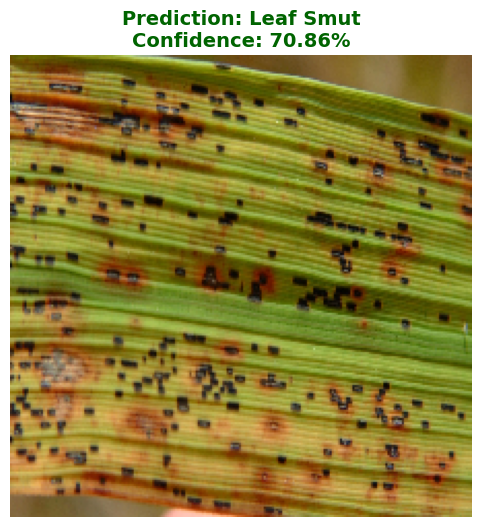

In [51]:
unseen_image_1=r"/content/drive/MyDrive/Dataset/leaf-smut_mk2.JPG"
predict_diesease(unseen_image_1)

Analyzing leaf...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


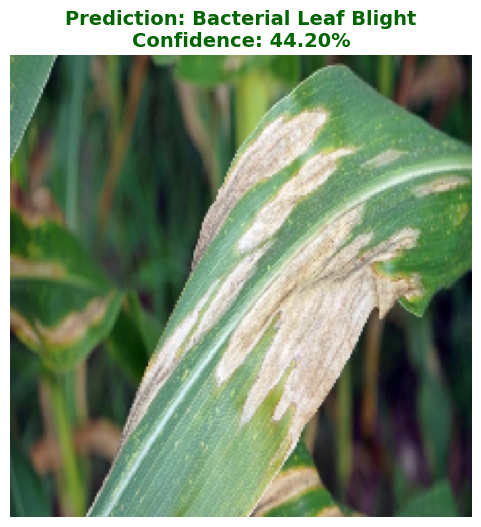

In [55]:
unseen_image2=r"/content/drive/MyDrive/Dataset/lb_leaf.jpg"
predict_diesease(unseen_image2)

Analyzing leaf...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


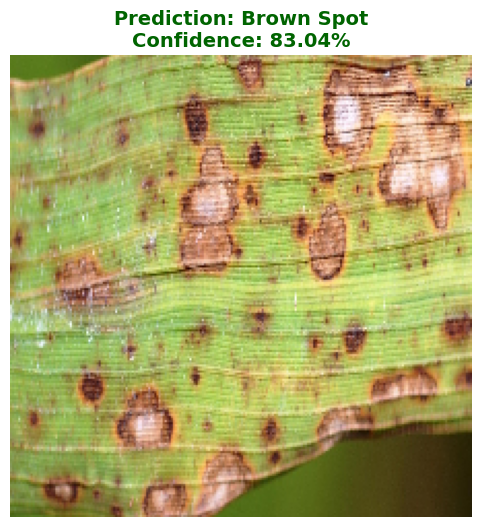

In [56]:
unseen_image3=r"/content/drive/MyDrive/Dataset/bs_leaf_4.jpg"
predict_diesease(unseen_image3)

<hr>